#import needed libreries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#LOAD DATA 

In [2]:
df = pd.read_csv('apy_1.csv')

In [3]:
df.shape

(73827, 8)

In [4]:
df.describe()

,Unnamed: 0,Crop_Year,Area,Production
count,73827.000000,73827.000000,7.382700e+04,7.273100e+04
mean,36913.000000,2005.657551,1.218297e+04,6.210320e+05
std,21312.163499,4.954910,5.348285e+04,1.749756e+07
min,0.000000,1997.000000,4.000000e-02,0.000000e+00
25%,18456.500000,2002.000000,8.100000e+01,8.900000e+01
50%,36913.000000,2006.000000,5.900000e+02,7.290000e+02
75%,55369.500000,2010.000000,4.500000e+03,7.200000e+03
max,73826.000000,2015.000000,8.580100e+06,1.125000e+09


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73827 entries, 0 to 73826
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     73827 non-null  int64  
 1   State_Name     73827 non-null  object 
 2   District_Name  73827 non-null  object 
 3   Crop_Year      73827 non-null  int64  
 4   Season         73827 non-null  object 
 5   Crop           73827 non-null  object 
 6   Area           73827 non-null  float64
 7   Production     72731 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 4.5+ MB


In [6]:
df.isnull().sum()

Unnamed: 0          0
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       1096
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.head()

,Unnamed: 0,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Bihar,NALANDA,1997,Rabi,Wheat,81934.0,160425.0
1,1,Assam,KARBI ANGLONG,2011,Whole Year,Onion,257.0,514.0
2,2,Gujarat,ANAND,2012,Summer,Maize,100.0,100.0
3,3,Karnataka,UTTAR KANNAD,2005,Rabi,Groundnut,2872.0,4572.0
4,4,Uttar Pradesh,JAUNPUR,2008,Rabi,Onion,110.0,1290.0


In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

In [10]:
print("percentage of missing values:")
print(missing_pct)

percentage of missing values:
Unnamed: 0       0.000000
State_Name       0.000000
District_Name    0.000000
Crop_Year        0.000000
Season           0.000000
Crop             0.000000
Area             0.000000
Production       1.484552
dtype: float64


In [11]:
ndf =  df[df.isnull().any(axis=1)]
ndf

,Unnamed: 0,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
133,133,Tamil Nadu,RAMANATHAPURAM,2010,Kharif,Horse-gram,1.0,NaN
135,135,Himachal Pradesh,BILASPUR,1998,Kharif,Small millets,1.0,NaN
427,427,Gujarat,BHARUCH,2004,Rabi,Other Rabi pulses,100.0,NaN
476,476,Haryana,GURGAON,2009,Whole Year,Sugarcane,5.0,NaN
495,495,Goa,SOUTH GOA,2008,Kharif,Groundnut,2.0,NaN
...,...,...,...,...,...,...,...,...
73423,73423,Odisha,PURI,2004,Kharif,Castor seed,7.0,NaN
73496,73496,Haryana,YAMUNANAGAR,2006,Kharif,Arhar/Tur,6.0,NaN
73604,73604,Madhya Pradesh,CHHINDWARA,2012,Whole Year,Banana,2.0,NaN
73632,73632,Haryana,YAMUNANAGAR,2008,Whole Year,Coriander,7.0,NaN


In [12]:
print(" let find the no. of nan of Production with respect to Area")
print("if Area > 500:")
print(df[(df['Production'].isnull()) & (df['Area'] > 500)].shape[0])
print("if Area <= 10:")
print(df[(df['Production'].isnull()) & (df['Area'] <= 10)].shape[0])
print("if Area > 100:")
print(df[(df['Production'].isnull()) & (df['Area'] > 100)].shape[0])


 let find the no. of nan of Production with respect to Area
if Area > 500:
77
if Area <= 10:
574
if Area > 100:
202


In [13]:
print(" let find  Area")
print("if Area > 500:")
print(df[(df['Area'] > 500)].shape[0])
print("if Area <= 10:")
print(df[(df['Area'] <= 10)].shape[0])
print("if Area > 100:")
print(df[(df['Area'] > 100)].shape[0])

 let find  Area
if Area > 500:
38272
if Area <= 10:
6926
if Area > 100:
53065


In [14]:
df['Crop_Year'] = df['Crop_Year'].astype(int)
df['Season'] = df['Season'].str.strip()
df['State_Name'] = df['State_Name'].str.strip()
df['Crop'] = df['Crop'].str.strip()

In [15]:
cy = ndf.groupby(['Crop_Year'])
cy.size()


Crop_Year
1998     86
1999     27
2000     30
2001     15
2002     39
2003     50
2004     76
2005    100
2006    108
2007     79
2008     89
2009     92
2010     82
2011     64
2012     57
2013     54
2014     47
2015      1
dtype: int64

In [16]:
st = ndf.groupby(['State_Name'])
st.size()

State_Name
Andhra Pradesh         21
Assam                   3
Bihar                   1
Chhattisgarh           96
Goa                     1
Gujarat                21
Haryana               375
Himachal Pradesh       10
Jammu and Kashmir       1
Karnataka              15
Kerala                 77
Madhya Pradesh         95
Maharashtra            41
Manipur                 1
Nagaland                2
Odisha                 22
Puducherry              2
Punjab                 10
Rajasthan             135
Tamil Nadu             80
Telangana              16
Uttar Pradesh          40
Uttarakhand            27
West Bengal             4
dtype: int64

In [17]:
cr = ndf.groupby(['Crop'])
cr.size()

Crop
Arecanut                    9
Arhar/Tur                  29
Bajra                      14
Banana                     23
Barley                     23
Black pepper               10
Blackgram                   5
Cardamom                   26
Cashewnut                   4
Castor seed                33
Coconut                     8
Coriander                  14
Cotton(lint)               35
Cowpea(Lobia)               9
Dry chillies               16
Dry ginger                  7
Garlic                     20
Gram                       39
Groundnut                  23
Guar seed                  16
Horse-gram                 19
Jack Fruit                  4
Jowar                      26
Jute                        8
Khesari                     2
Linseed                    12
Maize                      46
Masoor                     25
Mesta                       9
Moong(Green Gram)          59
Moth                       27
Niger seed                 12
Onion                       7
Other

In [18]:
se = ndf.groupby(['Season'])
se.size()

Season
Autumn           7
Kharif         485
Rabi           253
Summer          10
Whole Year     337
Winter           4
dtype: int64

In [19]:
nan_df = df[df['Production'].isnull()].copy()

print(" Area breakdown:")
print(f" Area <= 1   : {len(nan_df[nan_df['Area'] <= 1])} rows")
print(f" Area 1-10   : {len(nan_df[(nan_df['Area'] > 1) & (nan_df['Area'] <= 10)])} rows")
print(f" Area 10-100 : {len(nan_df[(nan_df['Area'] > 10) & (nan_df['Area'] <= 100)])} rows")
print(f" Area 100-500: {len(nan_df[(nan_df['Area'] > 100) & (nan_df['Area'] <= 500)])} rows")
print(f" Area > 500  : {len(nan_df[nan_df['Area'] > 500])} rows")

 Area breakdown:
 Area <= 1   : 319 rows
 Area 1-10   : 255 rows
 Area 10-100 : 320 rows
 Area 100-500: 125 rows
 Area > 500  : 77 rows


In [20]:
nan_df['has_similar_data'] = nan_df.apply(
    lambda row: df[
        (df['State_Name'] == row['State_Name']) & 
        (df['Crop'] == row['Crop']) & 
        (df['Season'] == row['Season']) &          
        (df['Production'].notna())
    ].shape[0] > 0,
    axis=1
)

print("NaN rows where same Crop+State+Season")
print(f" Can be filled : {nan_df['has_similar_data'].sum()} rows")
print(f" Cannot be filled: {(~nan_df['has_similar_data']).sum()} rows")

print("\nRows that can't be filled (no similar data exists):")
cannot_fill = nan_df[~nan_df['has_similar_data']][['State_Name', 'Crop', 'Season', 'Area', 'Crop_Year']]
cannot_fill
print(f" Total unfillable: {len(cannot_fill)}")

NaN rows where same Crop+State+Season
 Can be filled : 1023 rows
 Cannot be filled: 73 rows

Rows that can't be filled (no similar data exists):
 Total unfillable: 73


In [21]:
# Filling using State + Crop + Season median
new_df = df.copy()
new_df['Production'] = new_df.groupby(['State_Name', 'Crop', 'Season'])['Production'].transform(lambda x: x.fillna(x.median()))

In [22]:
new_df.isnull().sum()

Unnamed: 0        0
State_Name        0
District_Name     0
Crop_Year         0
Season            0
Crop              0
Area              0
Production       73
dtype: int64

In [23]:
new_df = new_df.dropna(subset=['Production'])

In [24]:
new_df.isnull().sum()

Unnamed: 0       0
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

In [25]:
new_df

,Unnamed: 0,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Bihar,NALANDA,1997,Rabi,Wheat,81934.00,160425.00
1,1,Assam,KARBI ANGLONG,2011,Whole Year,Onion,257.00,514.00
2,2,Gujarat,ANAND,2012,Summer,Maize,100.00,100.00
3,3,Karnataka,UTTAR KANNAD,2005,Rabi,Groundnut,2872.00,4572.00
4,4,Uttar Pradesh,JAUNPUR,2008,Rabi,Onion,110.00,1290.00
...,...,...,...,...,...,...,...,...
73822,73822,Bihar,BUXAR,2004,Whole Year,Onion,203.00,1918.00
73823,73823,Madhya Pradesh,RAJGARH,2013,Kharif,Bajra,12.00,11.00
73824,73824,Madhya Pradesh,RAJGARH,1998,Kharif,Groundnut,8700.00,9100.00
73825,73825,Rajasthan,TONK,2000,Kharif,Bajra,34477.00,20137.00


In [26]:
# Add yield column
new_df['Yield'] = new_df['Production'] / new_df['Area']

In [27]:
new_df

,Unnamed: 0,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,0,Bihar,NALANDA,1997,Rabi,Wheat,81934.00,160425.00,1.957978
1,1,Assam,KARBI ANGLONG,2011,Whole Year,Onion,257.00,514.00,2.000000
2,2,Gujarat,ANAND,2012,Summer,Maize,100.00,100.00,1.000000
3,3,Karnataka,UTTAR KANNAD,2005,Rabi,Groundnut,2872.00,4572.00,1.591922
4,4,Uttar Pradesh,JAUNPUR,2008,Rabi,Onion,110.00,1290.00,11.727273
...,...,...,...,...,...,...,...,...,...
73822,73822,Bihar,BUXAR,2004,Whole Year,Onion,203.00,1918.00,9.448276
73823,73823,Madhya Pradesh,RAJGARH,2013,Kharif,Bajra,12.00,11.00,0.916667
73824,73824,Madhya Pradesh,RAJGARH,1998,Kharif,Groundnut,8700.00,9100.00,1.045977
73825,73825,Rajasthan,TONK,2000,Kharif,Bajra,34477.00,20137.00,0.584071


In [28]:
# Drop unnecessary column
new_df.drop(columns=['Unnamed: 0'], inplace=True)

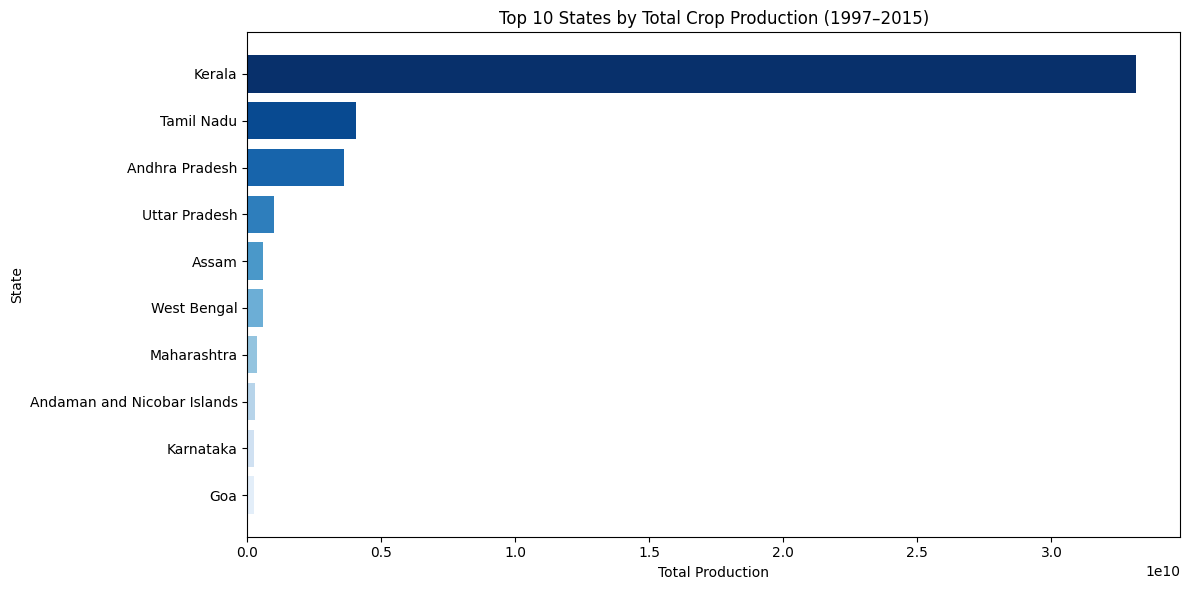

In [30]:
top_states = new_df.groupby('State_Name')['Production'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.barh(top_states['State_Name'], top_states['Production'],color=plt.cm.Blues_r([i/10 for i in range(10)]))
plt.xlabel('Total Production')
plt.ylabel('State')
plt.title('Top 10 States by Total Crop Production (1997–2015)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q1_top_states.png', dpi=150, bbox_inches='tight')
plt.show()

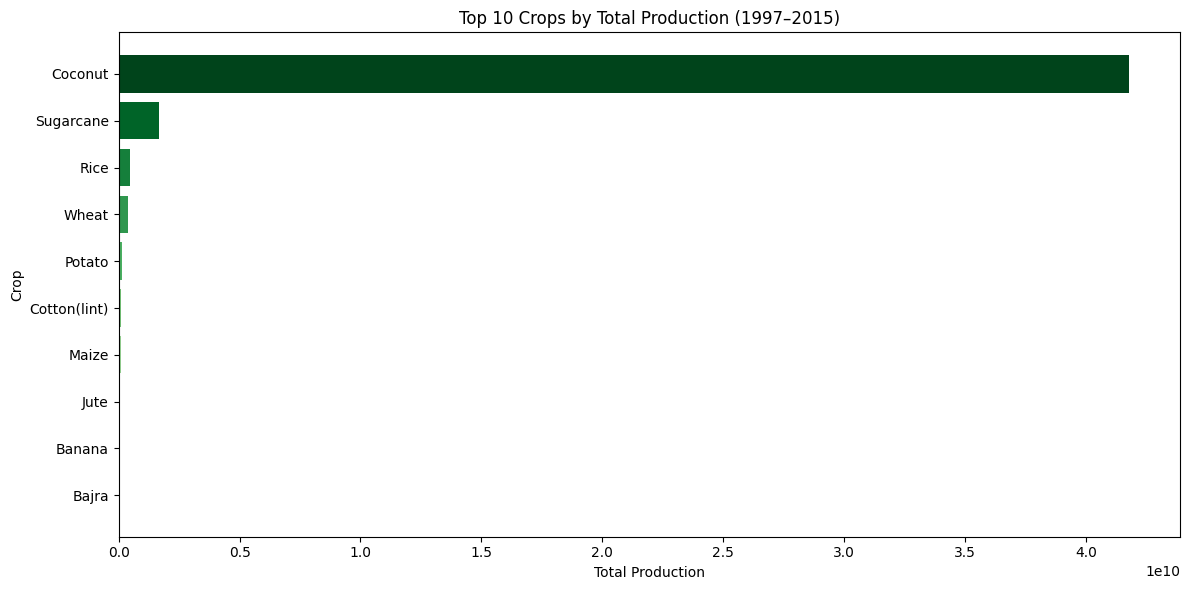

In [32]:
top_crops = new_df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
plt.barh(top_crops['Crop'], top_crops['Production'],color=plt.cm.Greens_r([i/10 for i in range(10)]))
plt.xlabel('Total Production')
plt.ylabel('Crop')
plt.title('Top 10 Crops by Total Production (1997–2015)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q2_top_crops.png', dpi=150, bbox_inches='tight')
plt.show()

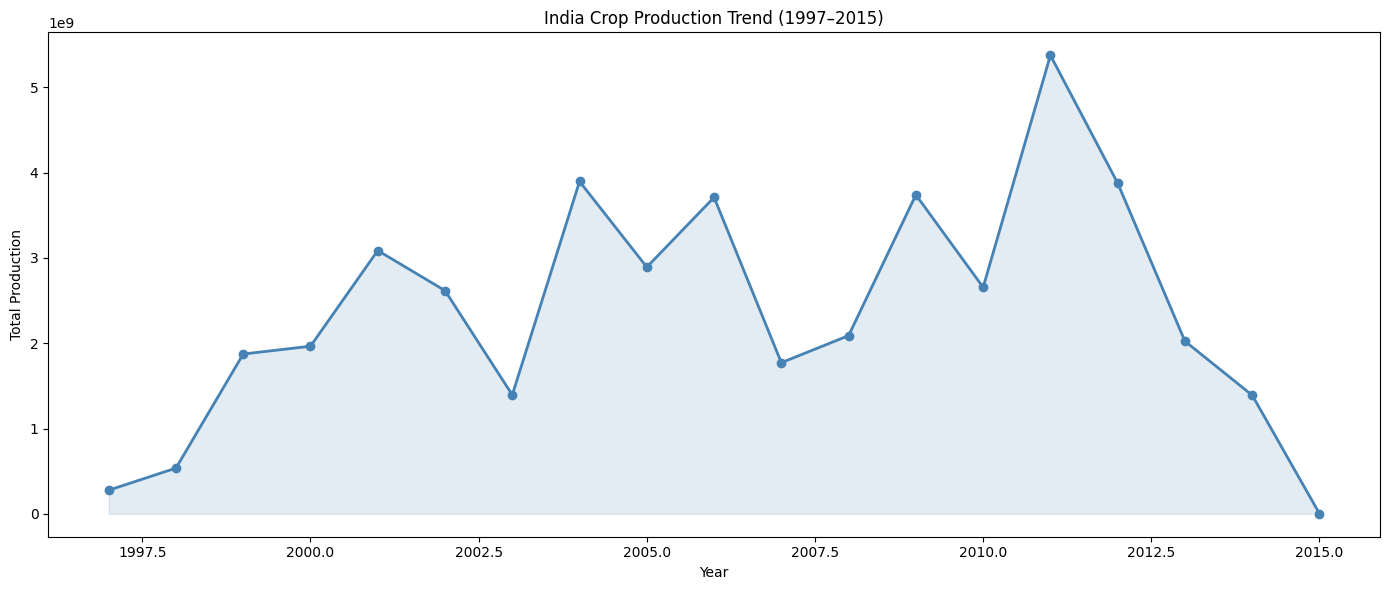

In [37]:
yearly = new_df.groupby('Crop_Year')['Production'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(yearly['Crop_Year'], yearly['Production'],marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(yearly['Crop_Year'], yearly['Production'],alpha=0.15, color='steelblue')
plt.xlabel('Year')
plt.ylabel('Total Production')
plt.title('India Crop Production Trend (1997–2015)')

plt.tight_layout()
plt.savefig('q3_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


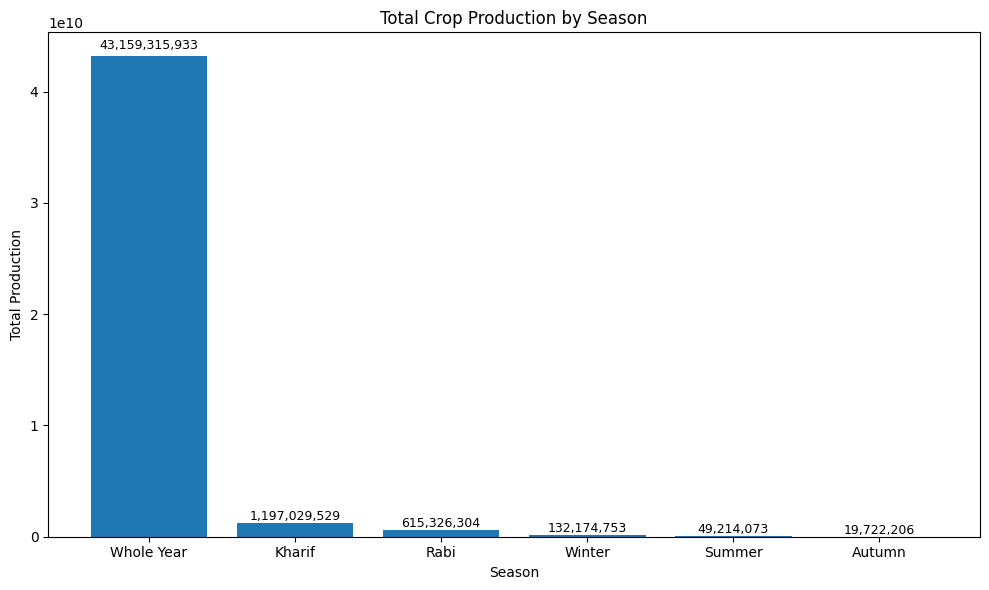

In [40]:
season_prod = new_df.groupby('Season')['Production'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 6))
bars = plt.bar(season_prod['Season'], season_prod['Production'])

# Add value labels on top of bars
for bar, val in zip(bars, season_prod['Production']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Season')
plt.ylabel('Total Production')
plt.title('Total Crop Production by Season')
plt.tight_layout()
plt.savefig('q4_season_production.png', dpi=150, bbox_inches='tight')
plt.show()

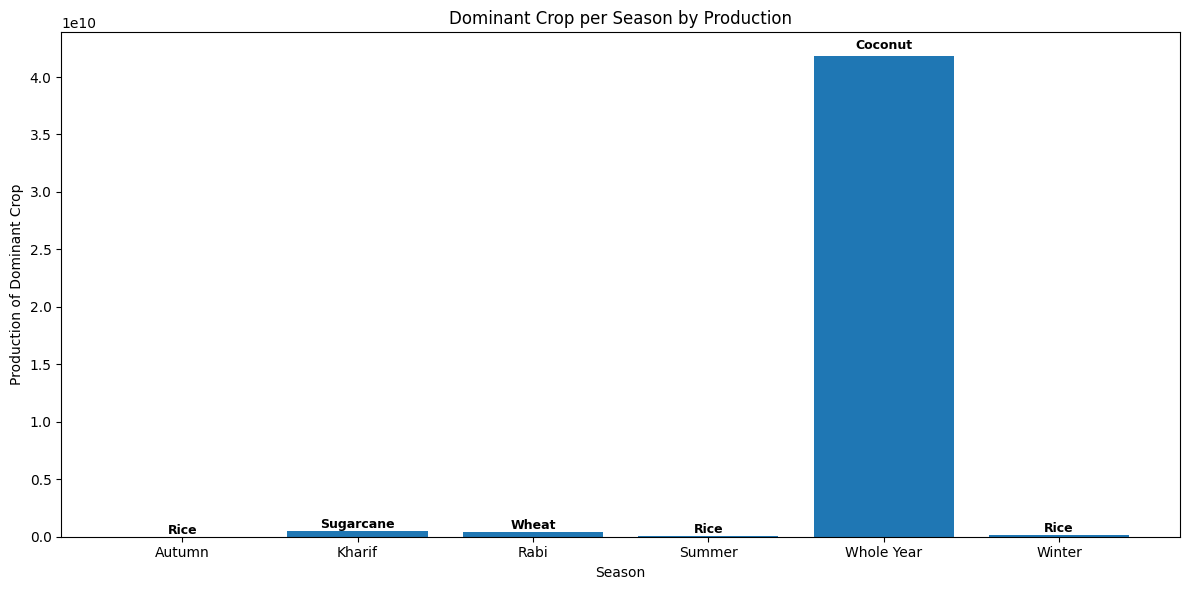

In [41]:
top_crop_season = (new_df.groupby(['Season', 'Crop'])['Production'].sum().reset_index().sort_values('Production', ascending=False).groupby('Season').first().reset_index())

plt.figure(figsize=(12, 6))
bars = plt.bar(top_crop_season['Season'],top_crop_season['Production'])

for bar, row in zip(bars, top_crop_season.itertuples()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             row.Crop, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Season')
plt.ylabel('Production of Dominant Crop')
plt.title('Dominant Crop per Season by Production')
plt.tight_layout()
plt.savefig('q5_top_crop_season.png', dpi=150, bbox_inches='tight')
plt.show()

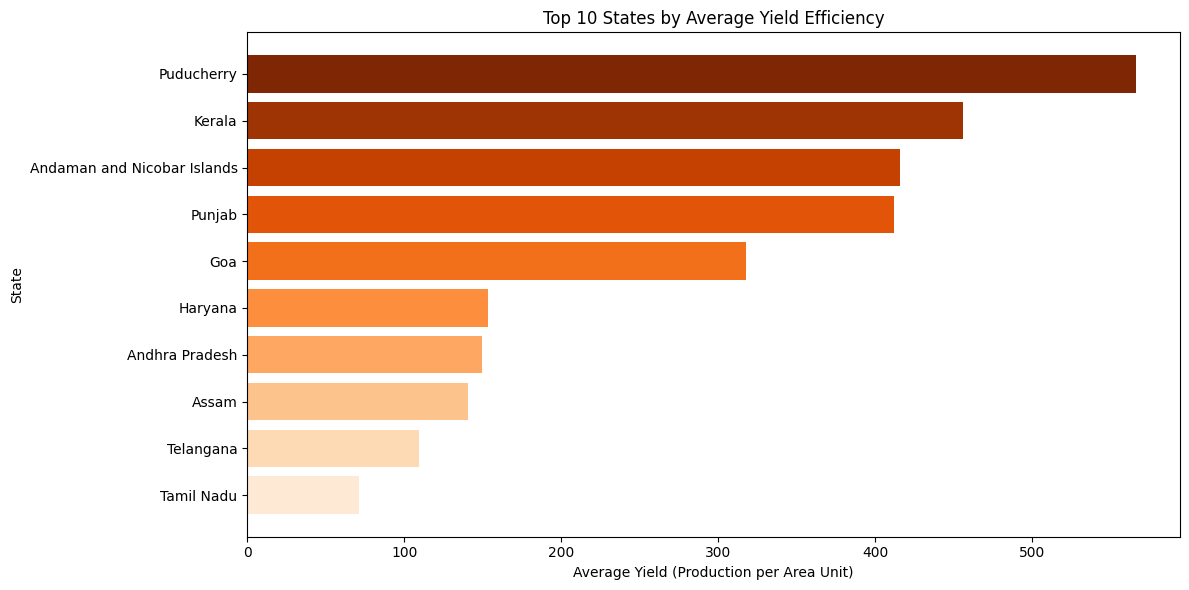

In [42]:
state_yield = new_df.groupby('State_Name')['Yield'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
plt.barh(state_yield['State_Name'], state_yield['Yield'],color=plt.cm.Oranges_r([i/10 for i in range(10)]))
plt.xlabel('Average Yield (Production per Area Unit)')
plt.ylabel('State')
plt.title('Top 10 States by Average Yield Efficiency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q6_yield_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

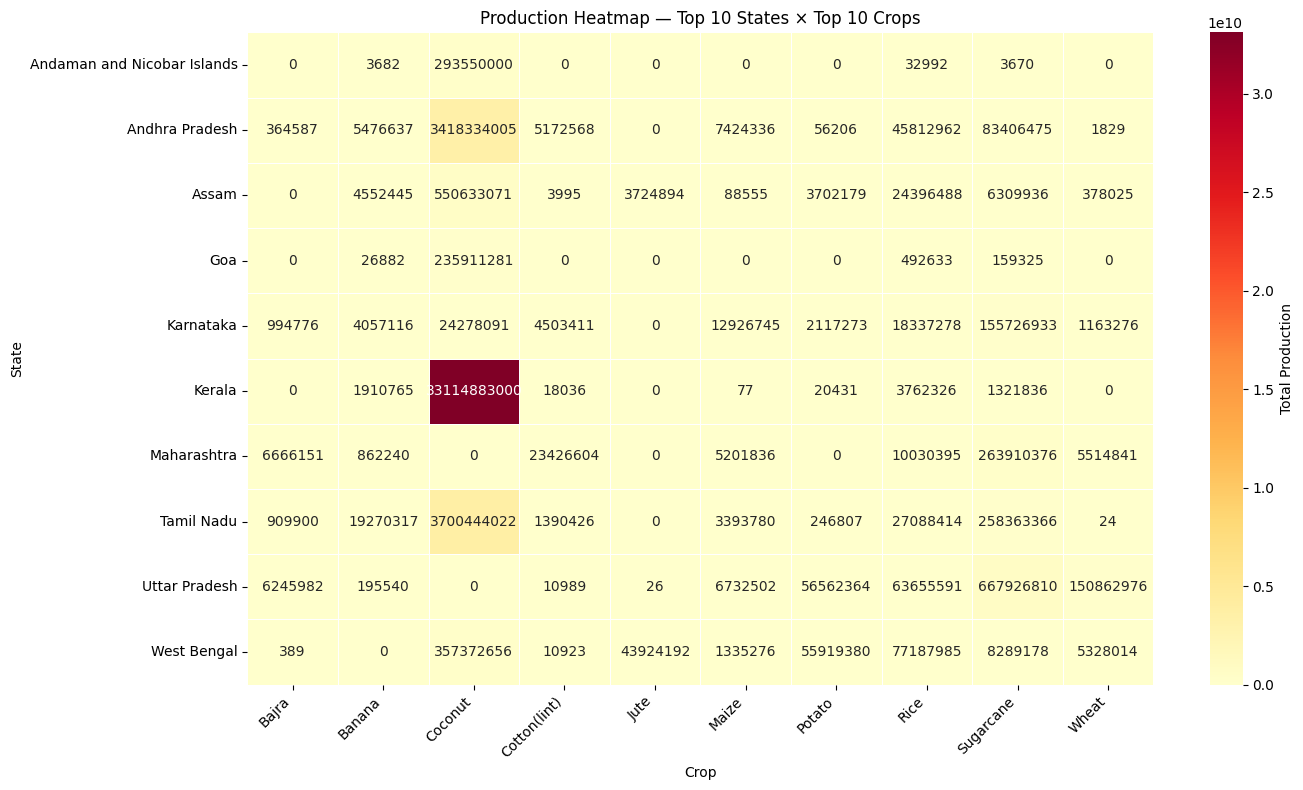

In [43]:
top10_states = new_df.groupby('State_Name')['Production'].sum().nlargest(10).index
top10_crops = new_df.groupby('Crop')['Production'].sum().nlargest(10).index

heatmap_data = new_df[new_df['State_Name'].isin(top10_states) & new_df['Crop'].isin(top10_crops)].groupby(['State_Name', 'Crop'])['Production'].sum().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data,cmap='YlOrRd',annot=True, fmt='.0f',linewidths=0.5,cbar_kws={'label': 'Total Production'})
plt.title('Production Heatmap — Top 10 States × Top 10 Crops')
plt.xlabel('Crop')
plt.ylabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('q6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
new_df.to_csv('new_df.csv', index=False)